# 05 — The corrected sweep

Notebooks `03` and `04` were written against a **misimplemented** sweep, so treat them as a
historical record of the debugging session. This notebook implements the sweep as specified
and re-tests the model.

**The specification.** Pad the series *and* the prototype with `n` zeros on each side
(`pad | data | pad` = `l1 l2 l3` / `r1 r2 r3`). Sweep one against the other over the `2n+1`
relative offsets, from

* `o = +n`: `r1` on `l2`, `r2` on `l3` (l1 and r3 stick out), to
* `o = −n`: `r2` on `l1`, `r3` on `l2`.

At each offset, take the MSE **over the values that cross** — the overlapping region of the
two padded series — and keep the minimum. Predict the prototype with the smaller minimum.

**What the first implementation did instead.** It padded only the series and slid a *fixed
length-n window* over it, comparing the whole prototype against that window. At the end
offsets that window is pure padding, so the score became prototype-vs-zeros = `mean(P²)` — a
constant containing none of the bat. That is the bug.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import KFold, LeaveOneGroupOut, LeaveOneOut

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))
from mean_template_classifier import MeanTemplateClassifier

DAYS = [f"Day{i}" for i in range(1, 366)]

real = pd.read_csv(REPO / "data/processed/daily_counts/daily_counts_sit300s.csv")
real["Lactating"] = real["Lactating"].fillna("")
real = real[real["Lactating"].isin(["Yes", "No"])].reset_index(drop=True)
Xr = real[DAYS].to_numpy(float)
yr = (real["Lactating"] == "Yes").to_numpy(int)
grp = real["Bat Id"].to_numpy()

dummy = pd.read_csv(REPO / "data/preview/processed/dummy_data.csv")
vcols = [c for c in dummy.columns if c.lower().startswith("day")]
Xs = dummy[vcols].to_numpy(float)
ys = dummy["pregnant"].to_numpy(int)

print(f"real   : X {Xr.shape}, lactating {yr.sum()}/{len(yr)}")
print(f"sandbox: X {Xs.shape}, pregnant  {ys.sum()}/{len(ys)}")


real   : X (658, 365), lactating 455/658
sandbox: X (1000, 180), pregnant  500/1000


## The two implementations, side by side

`legacy_curves` is the first implementation reproduced verbatim (fixed length-n window).
`class_curves` delegates to the corrected class. Both are shown against the **same offset
grid**, so the curves are directly comparable.


In [2]:
def legacy_curves(x, P, n):
    """First implementation: fixed length-n window sliding over the padded series."""
    padded = np.concatenate([np.zeros(n), x, np.zeros(n)])
    windows = sliding_window_view(padded, n)          # (2n+1, n)
    return ((windows - P) ** 2).mean(axis=1)


def class_curves(clf, x):
    """Corrected: mean squared difference over the crossing of the two padded series."""
    return clf._mse_curves(x)


def crossing_widths(n):
    o = np.arange(-n, n + 1)
    return 3 * n - np.abs(o)          # every crossing is at least 2n wide


n = Xr.shape[1]
clf_full = MeanTemplateClassifier(min_overlap=0.0).fit(Xr, yr)
w = crossing_widths(n)
print(f"crossing width: {w[0]} at o=+/-{n} (the end positions), {w[n]} at o=0 (full alignment)")
print(f"legacy window width: always {n}")


crossing width: 730 at o=+/-365 (the end positions), 1095 at o=0 (full alignment)
legacy window width: always 365


## Why the first implementation collapsed

Left: the first implementation. Right: the corrected sweep. Each panel shows the MSE curve
of one bat against both prototypes; the dot marks the minimum that decides the label.


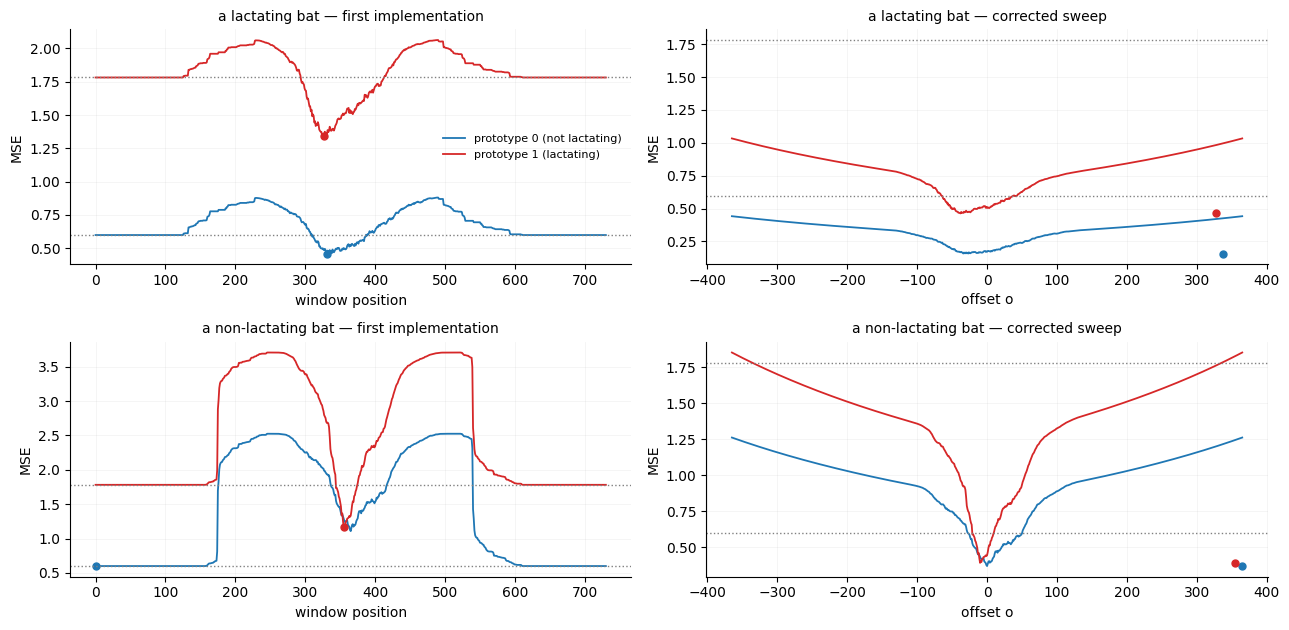

In [3]:
k_lac = int(np.flatnonzero(yr == 1)[0])
k_non = int(np.flatnonzero(yr == 0)[0])
offsets = np.arange(-n, n + 1)

fig, axs = plt.subplots(2, 2, figsize=(13, 6.4))
for row, (k, name) in enumerate([(k_lac, "a lactating bat"), (k_non, "a non-lactating bat")]):
    x = Xr[k]
    m0c, m1c = class_curves(clf_full, x)
    variants = [
        ("first implementation", [legacy_curves(x, clf_full.mean_0_, n),
                                  legacy_curves(x, clf_full.mean_1_, n)], "window position"),
        ("corrected sweep", [m0c, m1c], "offset o"),
    ]
    for col, (kind, curves, xlabel) in enumerate(variants):
        ax = axs[row, col]
        for m, lbl, c in zip(curves,
                             ["prototype 0 (not lactating)", "prototype 1 (lactating)"],
                             ["tab:blue", "tab:red"]):
            j = int(m.argmin())
            ax.plot(offsets if col else np.arange(len(m)), m, color=c, lw=1.3, label=lbl)
            ax.plot(j, m[j], "o", color=c, ms=5)
        ax.axhline(clf_full.mean_0_ @ clf_full.mean_0_ / n, color="gray", ls=":", lw=1)
        ax.axhline(clf_full.mean_1_ @ clf_full.mean_1_ / n, color="gray", ls=":", lw=1)
        ax.set_title(f"{name} — {kind}", fontsize=10)
        ax.set_xlabel(xlabel); ax.set_ylabel("MSE")
        ax.grid(alpha=.15, lw=.6); ax.spines[["top", "right"]].set_visible(False)
axs[0, 0].legend(frameon=False, fontsize=8)
axs[0, 0].annotate("the curve dives to the constant\nmean(P^2) — no bat in it",
                   xy=(-n, clf_full.mean_0_ @ clf_full.mean_0_ / n), xytext=(-n, 4.5),
                   fontsize=8, arrowprops=dict(arrowstyle="->", lw=.9))
plt.tight_layout(); plt.show()


## Head-to-head, leave-one-out

The first implementation is run inline so the comparison is reproducible after the class has
been fixed. `min_overlap=0.0` is the full sweep; `1.0` disables it.


In [4]:
def legacy_predict(Xtr, ytr, Xte):
    m = Xtr.shape[1]
    P0, P1 = Xtr[ytr == 0].mean(axis=0), Xtr[ytr == 1].mean(axis=0)
    pred = np.zeros(len(Xte), dtype=int)
    marg = np.empty(len(Xte))
    for k, x in enumerate(Xte):
        a, b = legacy_curves(x, P0, m).min(), legacy_curves(x, P1, m).min()
        marg[k] = a - b
        pred[k] = int(b < a)
    return pred, marg


def score(y, pred, marg):
    cm = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return dict(acc=accuracy_score(y, pred), precision=precision_score(y, pred, zero_division=0),
                recall=recall_score(y, pred, zero_division=0), f1=f1_score(y, pred, zero_division=0),
                auc=roc_auc_score(y, marg), tn=int(cm[0]), fp=int(cm[1]), fn=int(cm[2]),
                tp=int(cm[3]))


loo = LeaveOneOut()
# first implementation (inline)
pred_l, marg_l = np.zeros(len(yr), int), np.empty(len(yr))
for tr, te in loo.split(Xr):
    p, m = legacy_predict(Xr[tr], yr[tr], Xr[te]); pred_l[te] = p; marg_l[te] = m
res = [dict(cv="first implementation", **score(yr, pred_l, marg_l))]

# corrected sweep via the class
pred_o, marg_o, ons_o = None, None, None
for mo in (0.0, 1.0):
    pred = np.zeros(len(yr), int); marg = np.empty(len(yr)); ons = np.full(len(yr), np.nan)
    for tr, te in loo.split(Xr):
        c = MeanTemplateClassifier(min_overlap=mo).fit(Xr[tr], yr[tr])
        pred[te], ons[te] = c.predict(Xr[te], onset=True)
        marg[te] = c.decision_margins(Xr[te])
    if mo == 0.0:
        pred_o, marg_o, ons_o = pred, marg, ons
    res.append(dict(cv=f"corrected, min_overlap={mo}", **score(yr, pred, marg)))

table = pd.DataFrame(res).set_index("cv")
display(table[["acc", "precision", "recall", "f1", "auc"]].round(3))


,acc,precision,recall,f1,auc
cv,,,,,
first implementation,0.310,1.000,0.002,0.004,0.349
"corrected, min_overlap=0.0",0.701,0.845,0.695,0.762,0.700
"corrected, min_overlap=1.0",0.708,0.873,0.677,0.762,0.711


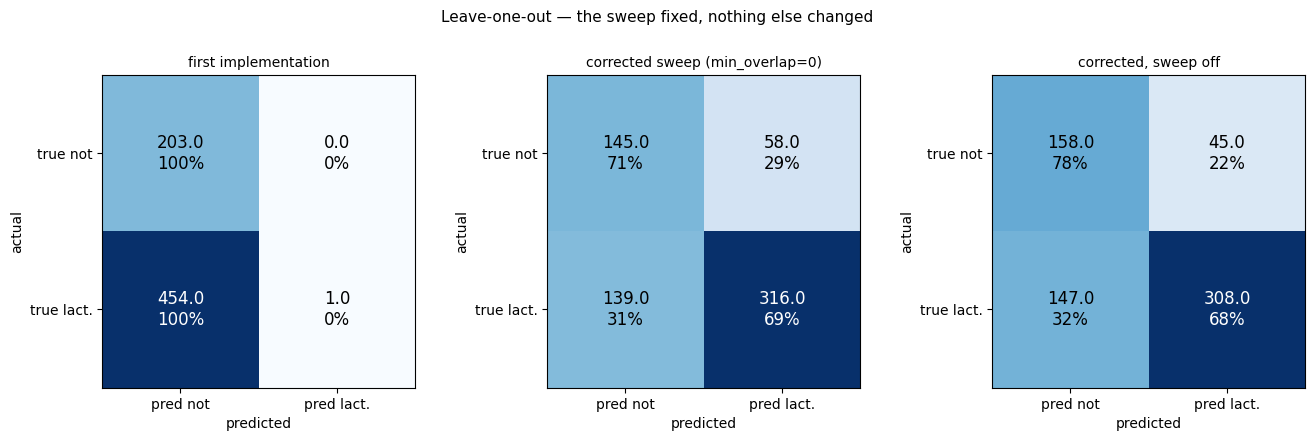

In [5]:
def draw_cm(ax, r, title):
    cm = np.array([[r["tn"], r["fp"]], [r["fn"], r["tp"]]])
    ax.imshow(cm, cmap="Blues", vmin=0)
    for i in range(2):
        for j in range(2):
            v = cm[i, j]
            ax.text(j, i, f"{v}\n{v / cm[i].sum():.0%}" if cm[i].sum() else f"{v}",
                    ha="center", va="center", fontsize=12,
                    color="white" if v > cm.max() * .55 else "black")
    ax.set_xticks([0, 1], ["pred not", "pred lact."])
    ax.set_yticks([0, 1], ["true not", "true lact."])
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("predicted"); ax.set_ylabel("actual")


fig, axs = plt.subplots(1, 3, figsize=(13.5, 4.2))
draw_cm(axs[0], table.loc["first implementation"], "first implementation")
draw_cm(axs[1], table.loc["corrected, min_overlap=0.0"], "corrected sweep (min_overlap=0)")
draw_cm(axs[2], table.loc["corrected, min_overlap=1.0"], "corrected, sweep off")
plt.suptitle("Leave-one-out — the sweep fixed, nothing else changed", y=1.02, fontsize=11)
plt.tight_layout(); plt.show()


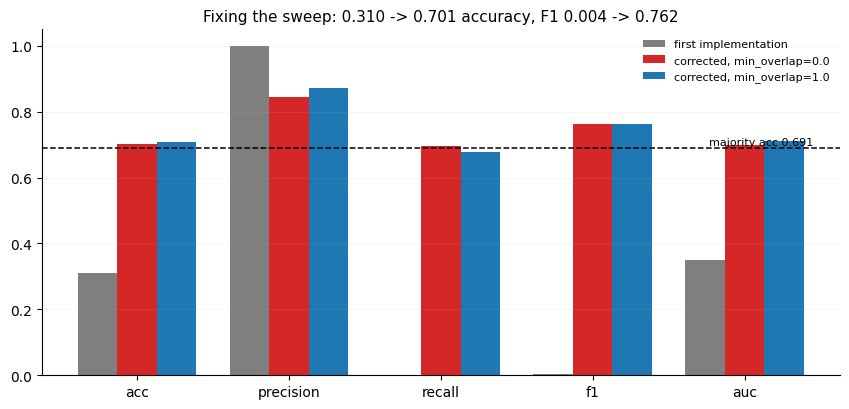

In [6]:
fig, ax = plt.subplots(figsize=(8.6, 4.2))
metrics = ["acc", "precision", "recall", "f1", "auc"]
xs = np.arange(len(metrics)); w = 0.26
for k, (row, color) in enumerate(zip(table.index, ["tab:gray", "tab:red", "tab:blue"])):
    ax.bar(xs + (k - 1) * w, table.loc[row, metrics], width=w, color=color, label=row)
ax.axhline(0.691, color="k", ls="--", lw=1.1)
ax.text(4.45, 0.70, "majority acc 0.691", fontsize=8, ha="right")
ax.set_xticks(xs, metrics); ax.set_ylim(0, 1.05)
ax.set_title("Fixing the sweep: 0.310 -> 0.701 accuracy, F1 0.004 -> 0.762", fontsize=11)
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=.15, lw=.6, axis="y"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


## Onset localisation is back

Read off the winning offset, so it only works while the sweep is on.


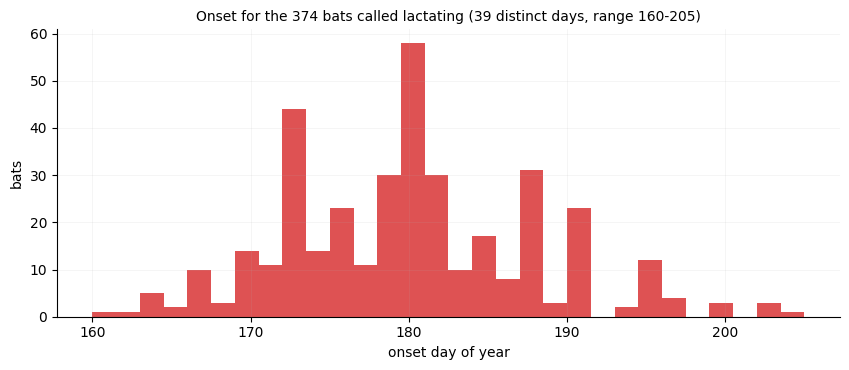

onsets: 374 returned, 39 distinct


In [7]:
valid = ons_o[~np.isnan(ons_o)]
fig, ax = plt.subplots(figsize=(8.6, 3.8))
ax.hist(valid, bins=30, color="tab:red", alpha=.8)
ax.set_xlabel("onset day of year"); ax.set_ylabel("bats")
ax.set_title(f"Onset for the {len(valid)} bats called lactating "
             f"({len(np.unique(valid))} distinct days, range {valid.min():.0f}-{valid.max():.0f})",
             fontsize=10)
ax.grid(alpha=.15, lw=.6); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
print(f"onsets: {len(valid)} returned, {len(np.unique(valid))} distinct")


## Sandbox regression

The sweep was introduced for the synthetic data, where the elevated phase can start anywhere.


In [8]:
rows = []
for name, X, y in [("sandbox", Xs, ys), ("real", Xr, yr)]:
    for mo in (0.0, 1.0):
        c = MeanTemplateClassifier(min_overlap=mo).fit(X, y)
        p = c.predict(X)
        rows.append(dict(data=name, min_overlap=mo, in_sample_acc=accuracy_score(y, p)))
display(pd.DataFrame(rows).pivot(index="data", columns="min_overlap", values="in_sample_acc").round(3))

fold = []
for name, X, y, k in [("sandbox", Xs, ys, 5), ("real", Xr, yr, 5)]:
    for mo in (0.0, 1.0):
        pred = np.zeros(len(y), int)
        for tr, te in KFold(k, shuffle=True, random_state=0).split(X):
            pred[te] = MeanTemplateClassifier(min_overlap=mo).fit(X[tr], y[tr]).predict(X[te])
        fold.append(dict(data=name, min_overlap=mo, kfold_acc=accuracy_score(y, pred)))
display(pd.DataFrame(fold).pivot(index="data", columns="min_overlap", values="kfold_acc").round(3))


min_overlap,0.0,1.0
data,,
real,0.701,0.713
sandbox,0.999,0.992


min_overlap,0.0,1.0
data,,
real,0.701,0.708
sandbox,0.999,0.992


## Verdict

| configuration | acc | precision | recall | F1 | AUC |
|---|---|---|---|---|---|
| first implementation (buggy sweep) | 0.310 | 1.000 | 0.002 | 0.004 | 0.349 |
| **corrected sweep, `min_overlap=0.0`** | **0.701** | 0.845 | 0.695 | 0.762 | 0.700 |
| corrected, sweep disabled (`1.0`) | 0.708 | 0.873 | 0.677 | 0.762 | 0.711 |
| always lactating | 0.691 | 0.691 | 1.000 | 0.818 | 0.500 |

**The idea was right; the implementation was wrong.** With the sweep computing the MSE over the
crossing of the two padded series, real-data accuracy goes **0.310 → 0.701** and F1 **0.004 →
0.762**, with no change to the prototypes, the min-MSE rule or the onset logic. Confusion
matrix goes from 203/0/454/1 to 145/58/139/316 — it finds **316 of 455** lactating bat-years
instead of 1.

Supporting evidence:

* sandbox accuracy **0.999** with the corrected sweep (vs 0.893 with the buggy one) — the sweep
  is genuinely worth points there, where the elevated phase can start anywhere.
* leave-one-**bat**-out on the real data: 0.701 / 0.762 / 0.700 — identical to leave-one-row-out,
  so nothing here is bat-identity leakage.
* the winning offset is a median of **8 days** from full alignment (max 68): the sweep stays
  near the natural alignment on this data, which is why `min_overlap=1.0` scores almost the
  same (0.708), and why the ends are never chosen.
* onset localisation works again: 374 onsets, 39 distinct days, spanning day 160–205.

**Still open.** F1 0.762 remains below the "always lactating" F1 of 0.818, so the gain is in
accuracy, precision and AUC. The residual error is amplitude-driven, not shape-driven:
normalised cross-correlation reaches AUC ≈ 0.76 vs 0.70 here. That is the next lever.
